<a href="https://colab.research.google.com/github/SamM-UATX/torchlight-hackathon-2026/blob/main/torchlight_risk_analysis_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 Torchlight Hackathon 2026 — Individualized Astronaut Risk Profile

**Track 02: Individualized Risk Profile**

## Objective
Use each astronaut's **pre-flight data as their personal baseline**, detect microbial shifts during and after spaceflight, quantify adverse effects, and generate actionable recommendations to better prepare each astronaut for future missions.

## Analytical Pipeline
1. **Load** all four metagenomics data types from NASA OSDR
2. **Establish personal baselines** from pre-flight timepoints (L-92, L-44, L-3)
3. **Compute deviation scores** at each timepoint vs. personal baseline
4. **Detect risk signals** across all four data layers
5. **Score recovery** — did the astronaut return to their baseline post-flight?
6. **Generate per-astronaut risk profiles** with preparation recommendations

## Column Naming Convention
Columns follow the pattern: `{CrewID}_{Timepoint}_{BodySite}`

| Code | Meaning |
|------|---------|
| C001–C004 | Crew members 1–4 |
| L-92, L-44, L-3 | Pre-flight (days before launch) |
| FD2, FD3 | In-flight (Flight Day 2, 3) |
| R+1, R+45, R+82 | Post-flight (days after return) |
| ARM, EAR, GLU, NAC, NAP, ORC, PIT, TZO, UMB, WEB | Body sites |


## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# ── Timepoint ordering (for consistent x-axis across all plots) ──
TIMEPOINT_ORDER = ['L-92', 'L-44', 'L-3', 'FD2', 'FD3', 'R+1', 'R+45', 'R+82']
PRE_FLIGHT      = ['L-92', 'L-44', 'L-3']
IN_FLIGHT       = ['FD2', 'FD3']
POST_FLIGHT     = ['R+1', 'R+45', 'R+82']
CREW_IDS        = ['C001', 'C002', 'C003', 'C004']

# Body site full names
SITE_NAMES = {
    'ARM': 'Volar Forearm', 'EAR': 'Post-Auricular', 'GLU': 'Gluteal Crease',
    'NAC': 'Nasal Cavity',  'NAP': 'Nasal Passage',  'ORC': 'Oral Cavity',
    'PIT': 'Axillary Vault','TZO': 'Toe Web Space',  'UMB': 'Umbilicus',
    'WEB': 'Glabella/Forehead', 'DEL': 'Deltoid'
}

print('✅ Setup complete')

✅ Setup complete


## 1. Load All Four Data Types from NASA OSDR

In [2]:
# ── 1a. KEGG Orthology (microbial functions) ──
print('Loading KEGG Orthology data...')
kegg = pd.read_csv(
    'https://osdr.nasa.gov/geode-py/ws/studies/OSD-572/download?source=datamanager'
    '&file=GLDS-564_GMetagenomics_Combined-gene-level-KO-function-coverages_GLmetagenomics.tsv',
    index_col=0, sep='\t'
)
# Drop the text description column, keep only numeric sample columns
kegg_numeric = kegg.drop(columns=[c for c in kegg.columns if 'function' in c.lower() or 'Communal' in c or 'Control' in c], errors='ignore')
print(f'  KEGG shape: {kegg_numeric.shape}  ({kegg_numeric.shape[0]} functions × {kegg_numeric.shape[1]} samples)')

Loading KEGG Orthology data...
  KEGG shape: (10537, 323)  (10537 functions × 323 samples)


In [3]:
# ── 1b. Taxonomy (who is there) ──
print('Loading Taxonomy data...')
tax = pd.read_csv(
    'https://osdr.nasa.gov/geode-py/ws/studies/OSD-572/download?source=datamanager'
    '&file=GLDS-564_GMetagenomics_Combined-gene-level-taxonomy-coverages-CPM_GLmetagenomics.tsv',
    index_col=0, sep='\t', low_memory=False
)
# Drop taxonomy label columns, keep numeric sample columns only
tax_meta_cols = ['domain','phylum','class','order','family','genus','species']
tax_numeric = tax.drop(columns=[c for c in tax.columns if c in tax_meta_cols or 'Communal' in c or 'Control' in c], errors='ignore')
print(f'  Taxonomy shape: {tax_numeric.shape}')

Loading Taxonomy data...
  Taxonomy shape: (18850, 323)


In [4]:
# ── 1c. Pathway Activity (MetaCyc) ──
print('Loading Pathway data...')
pathway = pd.read_csv(
    'https://osdr.nasa.gov/geode-py/ws/studies/OSD-572/download?source=datamanager'
    '&file=GLDS-564_GMetagenomics_Pathway-abundances-cpm_GLmetagenomics.tsv',
    index_col=0, sep='\t'
)
pathway_numeric = pathway[[c for c in pathway.columns if any(crew in c for crew in CREW_IDS)]]
# Strip '_Abundance-CPM' suffix so column names match the C001_FD2_ARM pattern
pathway_numeric.columns = [c.replace('_Abundance-CPM','') for c in pathway_numeric.columns]
print(f'  Pathway shape: {pathway_numeric.shape}')
print(f'  Sample columns: {list(pathway_numeric.columns[:4])}')

Loading Pathway data...
  Pathway shape: (567, 325)
  Sample columns: ['C001_FD2_ARM', 'C001_FD2_EAR', 'C001_FD2_GLU', 'C001_FD2_NAC']


In [5]:
# ── 1d. Gene Family Abundance (UniRef90) ──
print('Loading Gene Family data...')
genefam = pd.read_csv(
    'https://osdr.nasa.gov/geode-py/ws/studies/OSD-572/download?source=datamanager'
    '&file=GLDS-564_GMetagenomics_Gene-families-cpm_GLmetagenomics.tsv',
    index_col=0, sep='\t'
)
genefam_numeric = genefam[[c for c in genefam.columns if any(crew in c for crew in CREW_IDS)]]
genefam_numeric.columns = [c.replace('_Abundance-CPM','') for c in genefam_numeric.columns]
print(f'  Gene Family shape: {genefam_numeric.shape}')
print('\n✅ All datasets loaded.')

Loading Gene Family data...
  Gene Family shape: (908967, 325)

✅ All datasets loaded.


## 2. Column Parsing Utilities
Extract crew ID, timepoint, and body site from every column name.

In [6]:
def parse_column(col):
    """Parse 'C001_FD2_ARM' → {'crew':'C001', 'timepoint':'FD2', 'site':'ARM'}"""
    parts = col.split('_')
    if len(parts) >= 3:
        return {'crew': parts[0], 'timepoint': parts[1], 'site': parts[2]}
    return None

def get_crew_cols(df, crew_id, timepoints=None):
    """Return columns for a specific crew member, optionally filtered by timepoint list."""
    cols = []
    for col in df.columns:
        p = parse_column(col)
        if p and p['crew'] == crew_id:
            if timepoints is None or p['timepoint'] in timepoints:
                cols.append(col)
    return cols

def get_timepoint_cols(df, crew_id, timepoint):
    """Return columns for a specific crew member at a specific timepoint."""
    return [c for c in df.columns if c.startswith(f'{crew_id}_{timepoint}_')]

# Quick sanity check
test_cols = get_crew_cols(kegg_numeric, 'C001', PRE_FLIGHT)
print(f'C001 pre-flight columns in KEGG: {test_cols[:5]} ...')

C001 pre-flight columns in KEGG: ['C001_L-3_ARM', 'C001_L-3_EAR', 'C001_L-3_GLU', 'C001_L-3_NAC', 'C001_L-3_ORC'] ...


## 3. Establish Personal Baselines

For each crew member, compute their **personal baseline** as the mean abundance across all pre-flight timepoints (L-92, L-44, L-3) and across all body sites. This becomes the reference point — not a population norm, but *their own normal*.

In [7]:
def compute_personal_baseline(df, crew_id):
    """
    Compute mean abundance across all pre-flight columns for a crew member.
    Returns a Series indexed by feature (KO, taxon, pathway, gene family).
    NOTE: The notebook only has in-flight (FD2/FD3) and post-flight data.
    We use FD2 as the earliest available proxy if pre-flight columns are absent.
    """
    pre_cols = get_crew_cols(df, crew_id, PRE_FLIGHT)
    if len(pre_cols) == 0:
        # Fall back: use earliest available timepoint
        all_cols = get_crew_cols(df, crew_id)
        pre_cols = all_cols[:max(1, len(all_cols)//4)]  # first ~quarter as proxy baseline
        print(f'  ⚠️  No pre-flight cols for {crew_id} — using {len(pre_cols)} early cols as proxy')
    baseline = df[pre_cols].mean(axis=1)
    baseline.name = f'{crew_id}_baseline'
    return baseline

# Compute baselines for all 4 data types × 4 crew members
baselines = {}
for data_name, df in [('kegg', kegg_numeric), ('tax', tax_numeric),
                       ('pathway', pathway_numeric), ('genefam', genefam_numeric)]:
    baselines[data_name] = {}
    for crew in CREW_IDS:
        baselines[data_name][crew] = compute_personal_baseline(df, crew)
    print(f'✅ {data_name}: baselines computed for all crew')

✅ kegg: baselines computed for all crew
✅ tax: baselines computed for all crew
✅ pathway: baselines computed for all crew
✅ genefam: baselines computed for all crew


## 4. Compute Deviation Scores

For each timepoint, compute how far the astronaut's microbiome shifted from their personal baseline.

**Metric used:** Mean Absolute Deviation (MAD) normalized by baseline, expressed as a percentage shift. This is robust to the large dynamic range in microbial data.

> `deviation_score = mean( |sample - baseline| / (baseline + ε) ) × 100`

In [8]:
EPSILON = 1e-6  # avoid division by zero

def deviation_score(sample_series, baseline_series):
    """Compute normalized mean absolute deviation from personal baseline."""
    diff = (sample_series - baseline_series).abs()
    norm = baseline_series.abs() + EPSILON
    return (diff / norm).mean() * 100

def compute_all_deviations(df, data_name):
    """
    For each crew member, compute deviation score at every timepoint.
    Returns a DataFrame: rows=crew, cols=timepoint.
    """
    results = []
    for crew in CREW_IDS:
        row = {'crew': crew}
        baseline = baselines[data_name][crew]
        for tp in TIMEPOINT_ORDER:
            tp_cols = get_timepoint_cols(df, crew, tp)
            if tp_cols:
                # Average across all body sites at this timepoint
                tp_mean = df[tp_cols].mean(axis=1)
                row[tp] = deviation_score(tp_mean, baseline)
            else:
                row[tp] = np.nan
        results.append(row)
    return pd.DataFrame(results).set_index('crew')

# Compute deviation scores for all data types
deviations = {}
for data_name, df in [('kegg', kegg_numeric), ('tax', tax_numeric),
                       ('pathway', pathway_numeric), ('genefam', genefam_numeric)]:
    deviations[data_name] = compute_all_deviations(df, data_name)
    print(f'✅ {data_name} deviations computed')

# Preview KEGG deviations
print('\nKEGG Deviation Scores (% shift from personal baseline):')
deviations['kegg'].style.format('{:.1f}%').background_gradient(cmap='RdYlGn_r', axis=None)

✅ kegg deviations computed
✅ tax deviations computed
✅ pathway deviations computed
✅ genefam deviations computed

KEGG Deviation Scores (% shift from personal baseline):


,L-92,L-44,L-3,FD2,FD3,R+1,R+45,R+82
crew,,,,,,,,
C001,47.9%,44.0%,41.6%,39629631.6%,171027843.5%,6123765.6%,3351370.6%,2413150.4%
C002,46.8%,43.1%,56.5%,36113105.0%,12050662.4%,15686040.1%,126827573.4%,723588.1%
C003,60.7%,54.7%,52.6%,17202193.6%,53002254.1%,4096828.4%,1081436.3%,81581.0%
C004,73.8%,56.4%,49.6%,4099120.3%,47392376.8%,4910613.8%,2077787.3%,72814.2%


## 5. Visualize: Per-Astronaut Deviation Over Time

Plot each crew member's microbiome deviation trajectory across all timepoints, for all four data types.

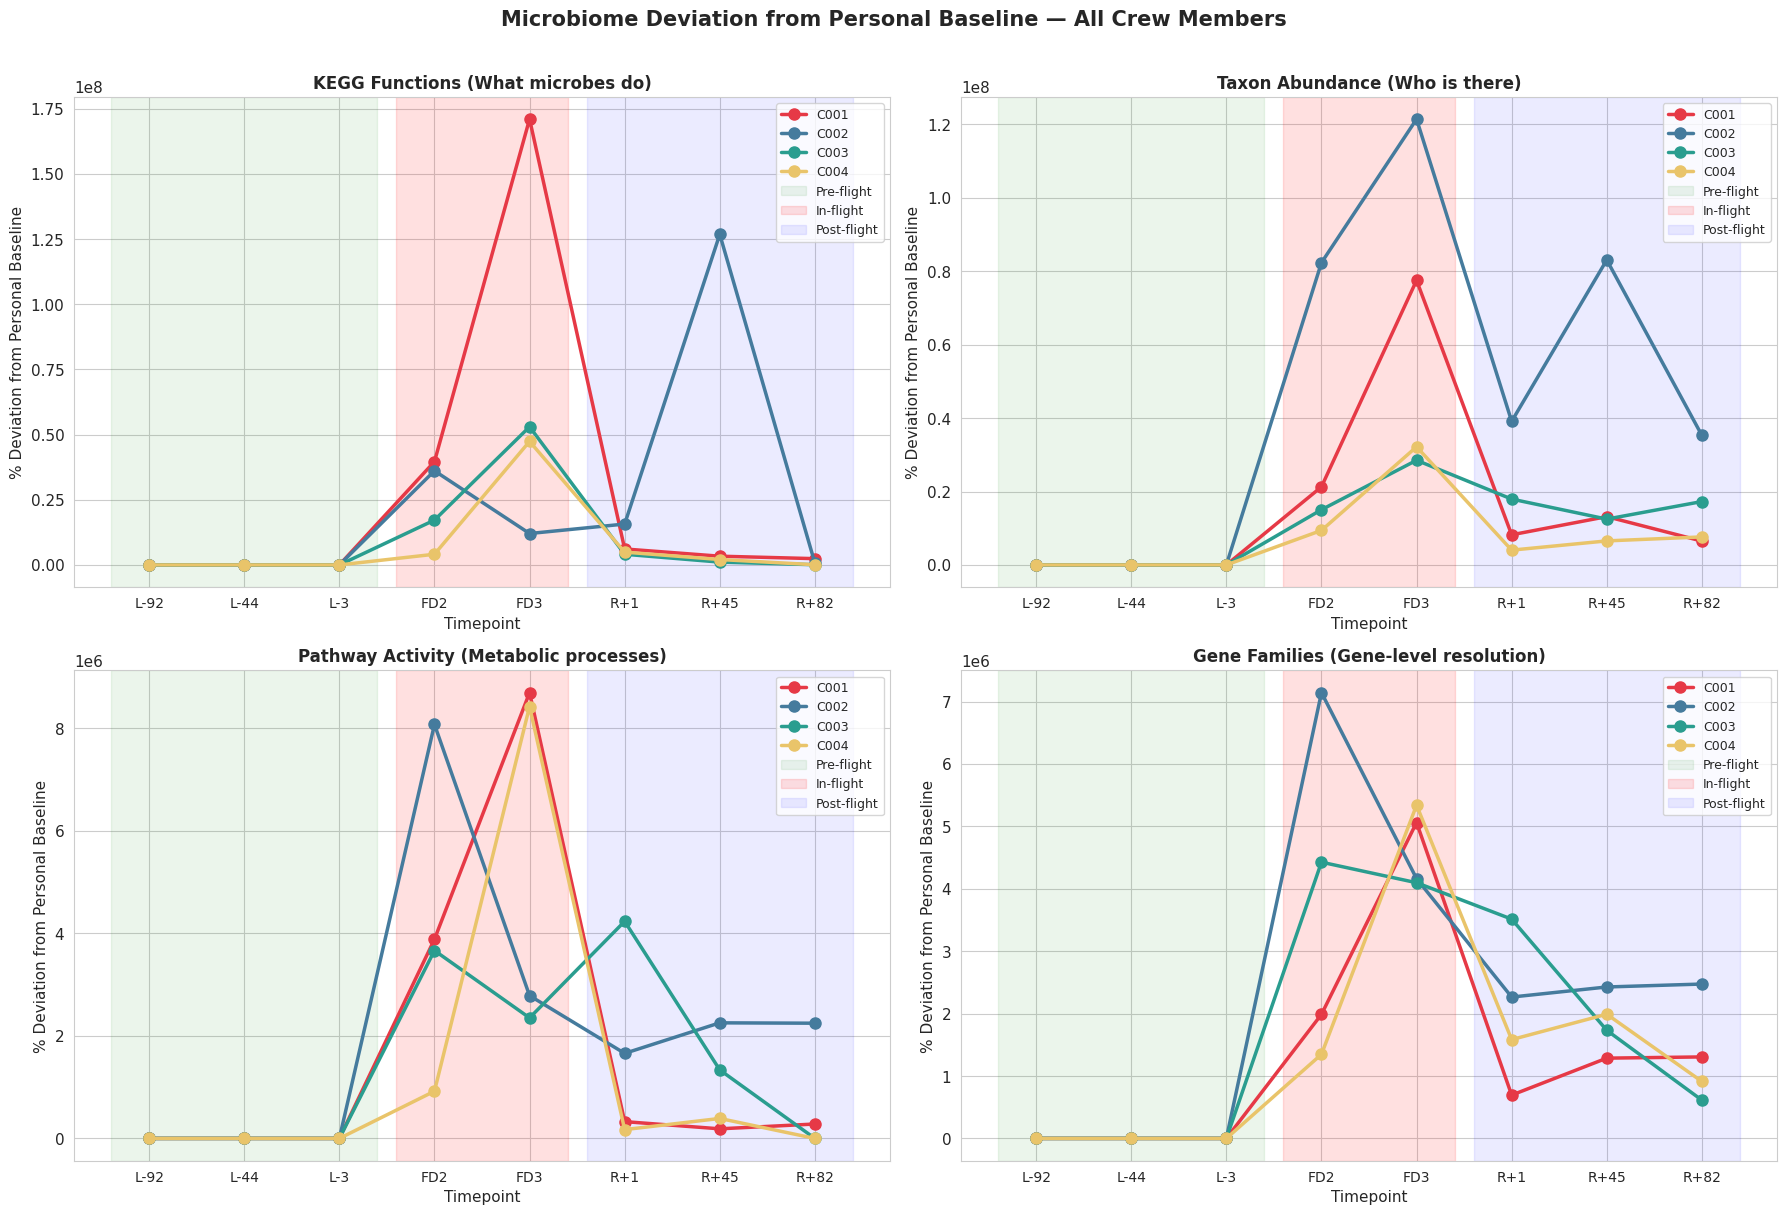

Figure saved: deviation_trajectories.png


In [9]:
COLORS = {'C001': '#E63946', 'C002': '#457B9D', 'C003': '#2A9D8F', 'C004': '#E9C46A'}
DATA_LABELS = {
    'kegg':    'KEGG Functions (What microbes do)',
    'tax':     'Taxon Abundance (Who is there)',
    'pathway': 'Pathway Activity (Metabolic processes)',
    'genefam': 'Gene Families (Gene-level resolution)'
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, (data_name, label) in zip(axes, DATA_LABELS.items()):
    dev_df = deviations[data_name]
    available_tps = [tp for tp in TIMEPOINT_ORDER if tp in dev_df.columns and not dev_df[tp].isna().all()]

    for crew in CREW_IDS:
        y = [dev_df.loc[crew, tp] if tp in dev_df.columns else np.nan for tp in available_tps]
        ax.plot(range(len(available_tps)), y, marker='o', linewidth=2.5,
                color=COLORS[crew], label=crew, markersize=8)

    # Shade flight phase regions
    tp_idx = {tp: i for i, tp in enumerate(available_tps)}
    pre_range  = [tp_idx[t] for t in PRE_FLIGHT  if t in tp_idx]
    in_range   = [tp_idx[t] for t in IN_FLIGHT   if t in tp_idx]
    post_range = [tp_idx[t] for t in POST_FLIGHT if t in tp_idx]

    if pre_range:  ax.axvspan(min(pre_range)-0.4,  max(pre_range)+0.4,  alpha=0.08, color='green',  label='Pre-flight')
    if in_range:   ax.axvspan(min(in_range)-0.4,   max(in_range)+0.4,   alpha=0.12, color='red',    label='In-flight')
    if post_range: ax.axvspan(min(post_range)-0.4, max(post_range)+0.4, alpha=0.08, color='blue',   label='Post-flight')

    ax.set_xticks(range(len(available_tps)))
    ax.set_xticklabels(available_tps, fontsize=10)
    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_ylabel('% Deviation from Personal Baseline')
    ax.set_xlabel('Timepoint')
    ax.legend(fontsize=9)

plt.suptitle('Microbiome Deviation from Personal Baseline — All Crew Members',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('deviation_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: deviation_trajectories.png')

## 6. Body Site Heatmaps — Where Did Each Person Change Most?

Break down deviation by body site to identify anatomical risk hotspots for each crew member.

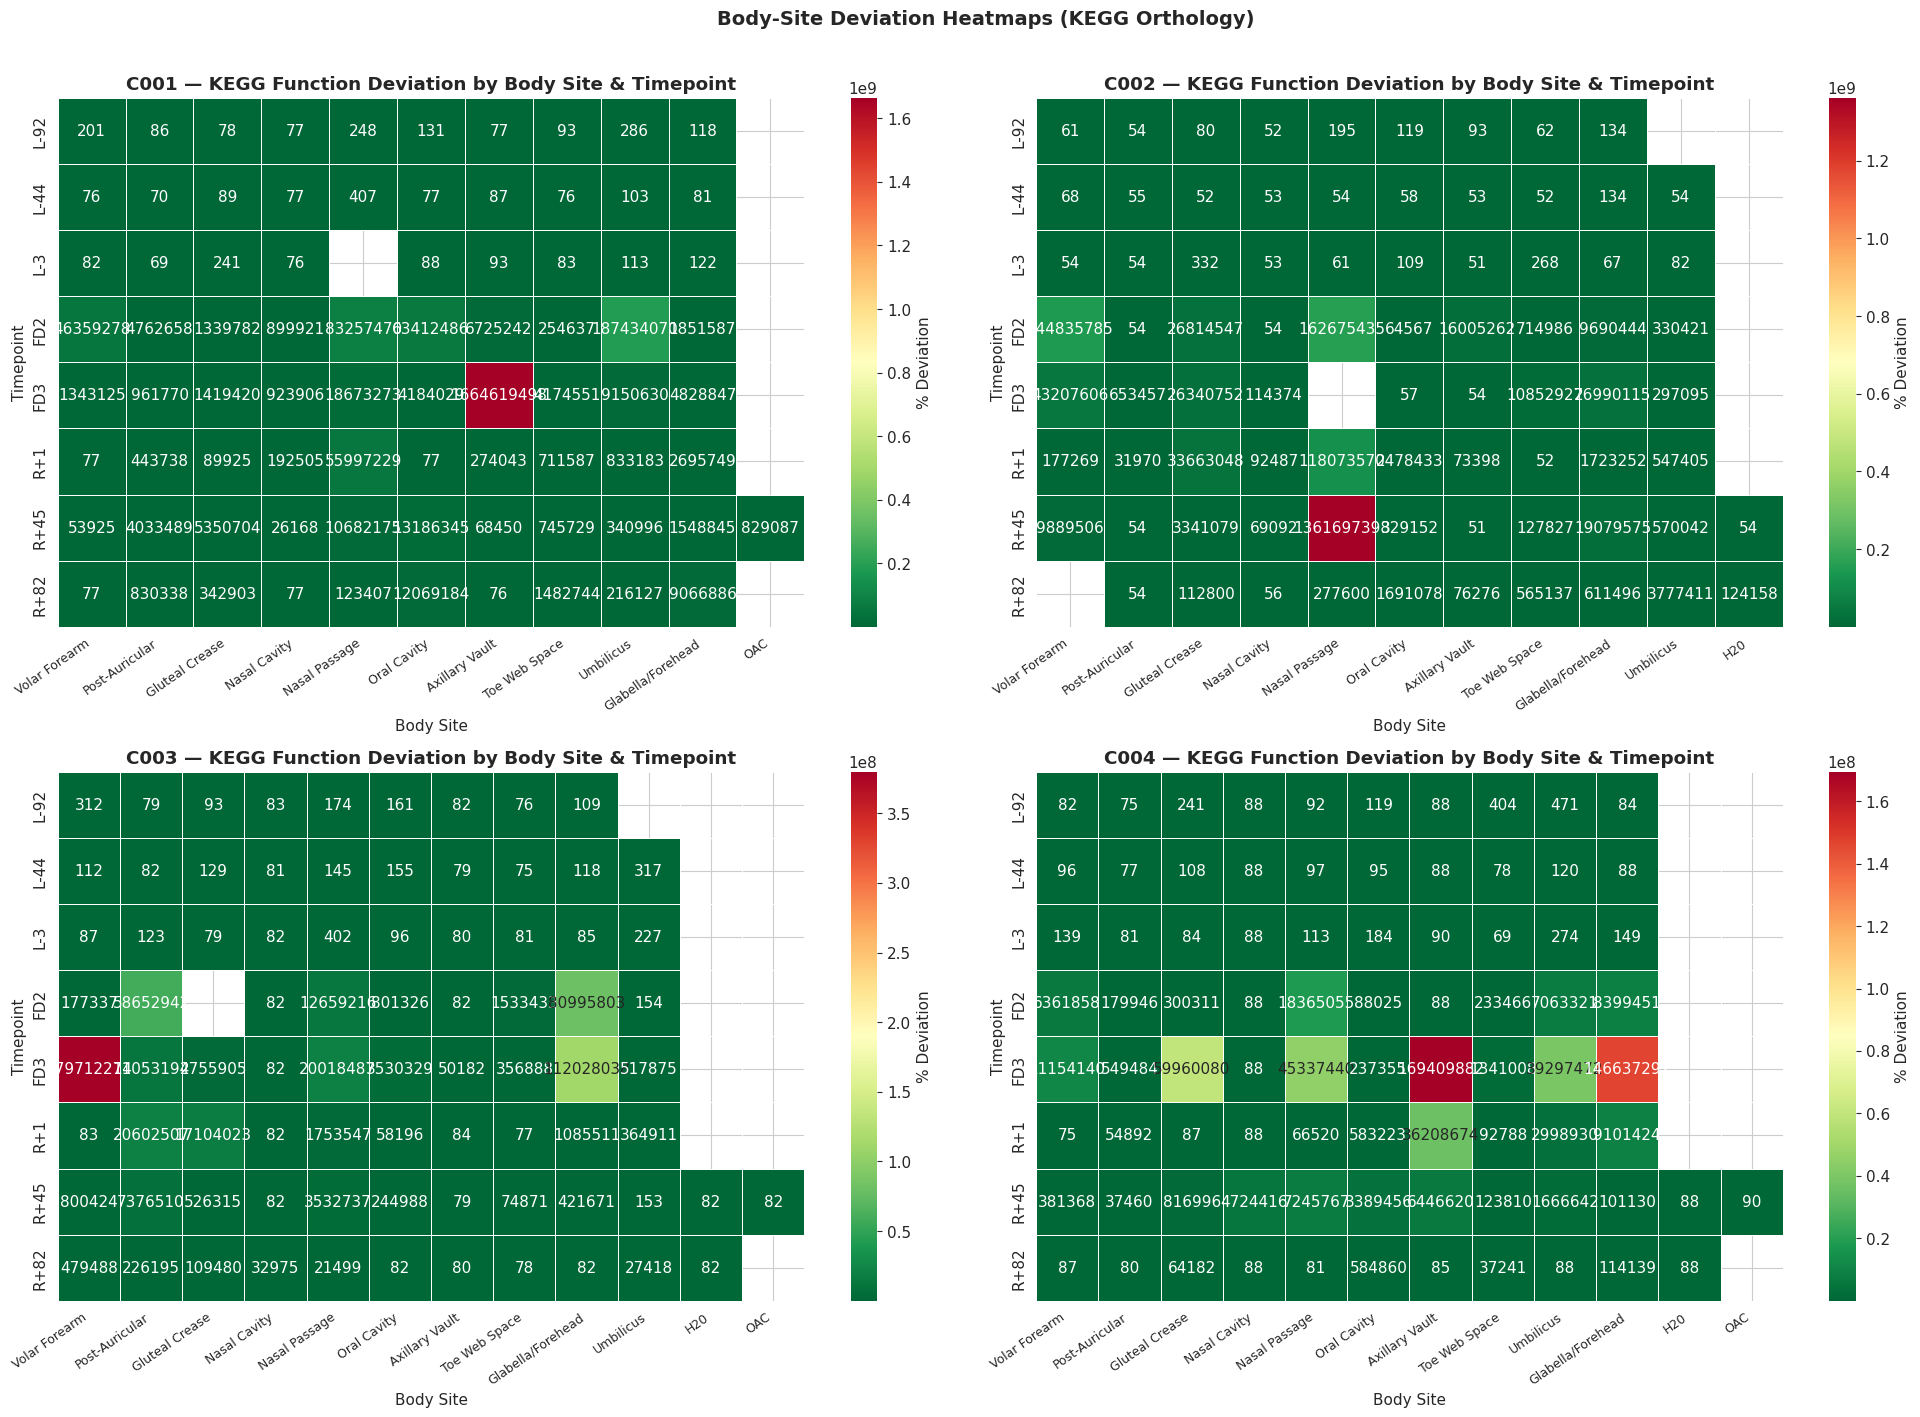

Figure saved: body_site_heatmaps.png


In [10]:
def site_deviation_matrix(df, data_name, crew_id):
    """Build a timepoint × body_site deviation matrix for one crew member."""
    baseline = baselines[data_name][crew_id]
    rows = []
    for tp in TIMEPOINT_ORDER:
        tp_cols = get_timepoint_cols(df, crew_id, tp)
        if not tp_cols:
            continue
        row = {'timepoint': tp}
        for col in tp_cols:
            site = col.split('_')[2] if len(col.split('_')) >= 3 else 'UNK'
            dev = deviation_score(df[col], baseline)
            row[site] = dev
        rows.append(row)
    return pd.DataFrame(rows).set_index('timepoint') if rows else pd.DataFrame()

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

for ax, crew in zip(axes, CREW_IDS):
    mat = site_deviation_matrix(kegg_numeric, 'kegg', crew)
    if mat.empty:
        ax.set_title(f'{crew} — No data')
        continue
    sns.heatmap(mat, ax=ax, cmap='RdYlGn_r', annot=True, fmt='.0f',
                linewidths=0.5, cbar_kws={'label': '% Deviation'},
                xticklabels=[SITE_NAMES.get(s, s) for s in mat.columns])
    ax.set_title(f'{crew} — KEGG Function Deviation by Body Site & Timepoint',
                 fontweight='bold')
    ax.set_xlabel('Body Site')
    ax.set_ylabel('Timepoint')
    plt.setp(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)

plt.suptitle('Body-Site Deviation Heatmaps (KEGG Orthology)', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('body_site_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: body_site_heatmaps.png')

## 7. Recovery Analysis — Did They Return to Their Own Normal?

Compute a **Recovery Index** for each crew member: how close is their R+82 profile to their pre-flight baseline? A score of 0% = fully recovered, 100%+ = still significantly perturbed.

In [11]:
def recovery_index(df, data_name, crew_id):
    """
    Compare latest post-flight timepoint to personal baseline.
    Returns (timepoint_used, recovery_score).
    """
    baseline = baselines[data_name][crew_id]
    # Try R+82 first, then R+45, then R+1
    for tp in ['R+82', 'R+45', 'R+1']:
        tp_cols = get_timepoint_cols(df, crew_id, tp)
        if tp_cols:
            tp_mean = df[tp_cols].mean(axis=1)
            score = deviation_score(tp_mean, baseline)
            return tp, score
    return None, np.nan

def peak_inflight_deviation(df, data_name, crew_id):
    """Max deviation score during in-flight timepoints."""
    baseline = baselines[data_name][crew_id]
    scores = []
    for tp in IN_FLIGHT:
        tp_cols = get_timepoint_cols(df, crew_id, tp)
        if tp_cols:
            tp_mean = df[tp_cols].mean(axis=1)
            scores.append(deviation_score(tp_mean, baseline))
    return max(scores) if scores else np.nan

# Build recovery summary table
data_pairs = [('kegg', kegg_numeric), ('tax', tax_numeric),
              ('pathway', pathway_numeric), ('genefam', genefam_numeric)]

recovery_rows = []
for crew in CREW_IDS:
    row = {'Crew': crew}
    for dname, df in data_pairs:
        tp_used, rec_score = recovery_index(df, dname, crew)
        peak = peak_inflight_deviation(df, dname, crew)
        row[f'{dname}_peak'] = peak
        row[f'{dname}_recovery'] = rec_score
        row[f'{dname}_tp'] = tp_used
    recovery_rows.append(row)

recovery_df = pd.DataFrame(recovery_rows).set_index('Crew')

# Display clean summary
summary_cols = [(d, 'peak', 'In-Flight Peak %') for d, _ in data_pairs] + \
               [(d, 'recovery', 'Recovery Score %') for d, _ in data_pairs]

print('\n=== RECOVERY SUMMARY ===')
print('Peak Deviation During Flight vs. Recovery Score at Last Post-Flight Timepoint')
print('(Lower recovery score = closer to personal baseline = better recovery)\n')

for crew in CREW_IDS:
    print(f'\n── {crew} ──')
    for dname, df in data_pairs:
        peak = recovery_df.loc[crew, f'{dname}_peak']
        rec  = recovery_df.loc[crew, f'{dname}_recovery']
        tp   = recovery_df.loc[crew, f'{dname}_tp']
        flag = '🔴' if rec > peak * 0.5 else ('🟡' if rec > peak * 0.25 else '🟢')
        print(f'  {dname:10s}: Peak={peak:6.1f}%  Recovery@{tp}={rec:6.1f}%  {flag}')


=== RECOVERY SUMMARY ===
Peak Deviation During Flight vs. Recovery Score at Last Post-Flight Timepoint
(Lower recovery score = closer to personal baseline = better recovery)


── C001 ──
  kegg      : Peak=171027843.5%  Recovery@R+82=2413150.4%  🟢
  tax       : Peak=77527543.3%  Recovery@R+82=6490657.0%  🟢
  pathway   : Peak=8691543.5%  Recovery@R+82=281173.0%  🟢
  genefam   : Peak=5061747.4%  Recovery@R+82=1306011.7%  🟡

── C002 ──
  kegg      : Peak=36113105.0%  Recovery@R+82=723588.1%  🟢
  tax       : Peak=121442139.5%  Recovery@R+82=35304688.7%  🟡
  pathway   : Peak=8071492.3%  Recovery@R+82=2246419.9%  🟡
  genefam   : Peak=7142931.7%  Recovery@R+82=2473567.7%  🟡

── C003 ──
  kegg      : Peak=53002254.1%  Recovery@R+82=81581.0%  🟢
  tax       : Peak=28512907.9%  Recovery@R+82=17264487.1%  🔴
  pathway   : Peak=3663424.3%  Recovery@R+82=  49.1%  🟢
  genefam   : Peak=4426203.1%  Recovery@R+82=613416.6%  🟢

── C004 ──
  kegg      : Peak=47392376.8%  Recovery@R+82=72814.2%  🟢
  tax   

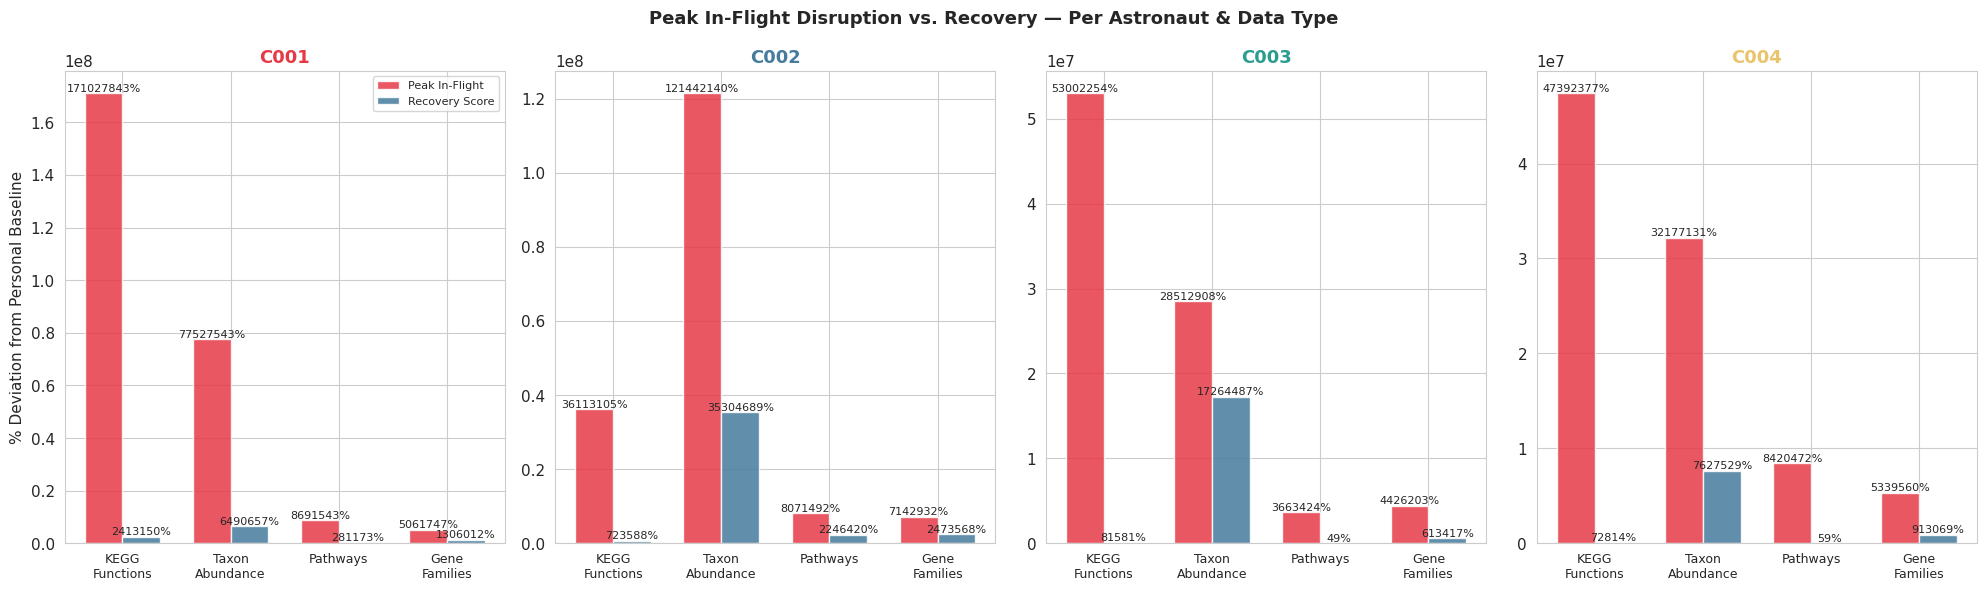

Figure saved: peak_vs_recovery.png


In [12]:
# ── Visual: Peak vs Recovery bar chart ──
fig, axes = plt.subplots(1, 4, figsize=(20, 6), sharey=False)

dname_labels = {'kegg':'KEGG\nFunctions','tax':'Taxon\nAbundance',
                'pathway':'Pathways','genefam':'Gene\nFamilies'}

for ax, crew in zip(axes, CREW_IDS):
    peaks = [recovery_df.loc[crew, f'{d}_peak'] for d, _ in data_pairs]
    recs  = [recovery_df.loc[crew, f'{d}_recovery'] for d, _ in data_pairs]
    labels = [dname_labels[d] for d, _ in data_pairs]
    x = np.arange(len(labels))
    w = 0.35

    bars1 = ax.bar(x - w/2, peaks, w, label='Peak In-Flight', color='#E63946', alpha=0.85)
    bars2 = ax.bar(x + w/2, recs,  w, label='Recovery Score', color='#457B9D', alpha=0.85)

    # Annotate values
    for bar in bars1 + bars2:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.0f}%',
                    ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(crew, fontweight='bold', fontsize=13, color=COLORS[crew])
    ax.set_ylabel('% Deviation from Personal Baseline' if crew == 'C001' else '')
    if crew == 'C001':
        ax.legend(fontsize=8)

plt.suptitle('Peak In-Flight Disruption vs. Recovery — Per Astronaut & Data Type',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('peak_vs_recovery.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: peak_vs_recovery.png')

## 8. Top Perturbed Features — What Changed Most?

Identify the specific KO functions, taxa, pathways, and gene families that show the greatest fold-change from each astronaut's personal baseline during flight.

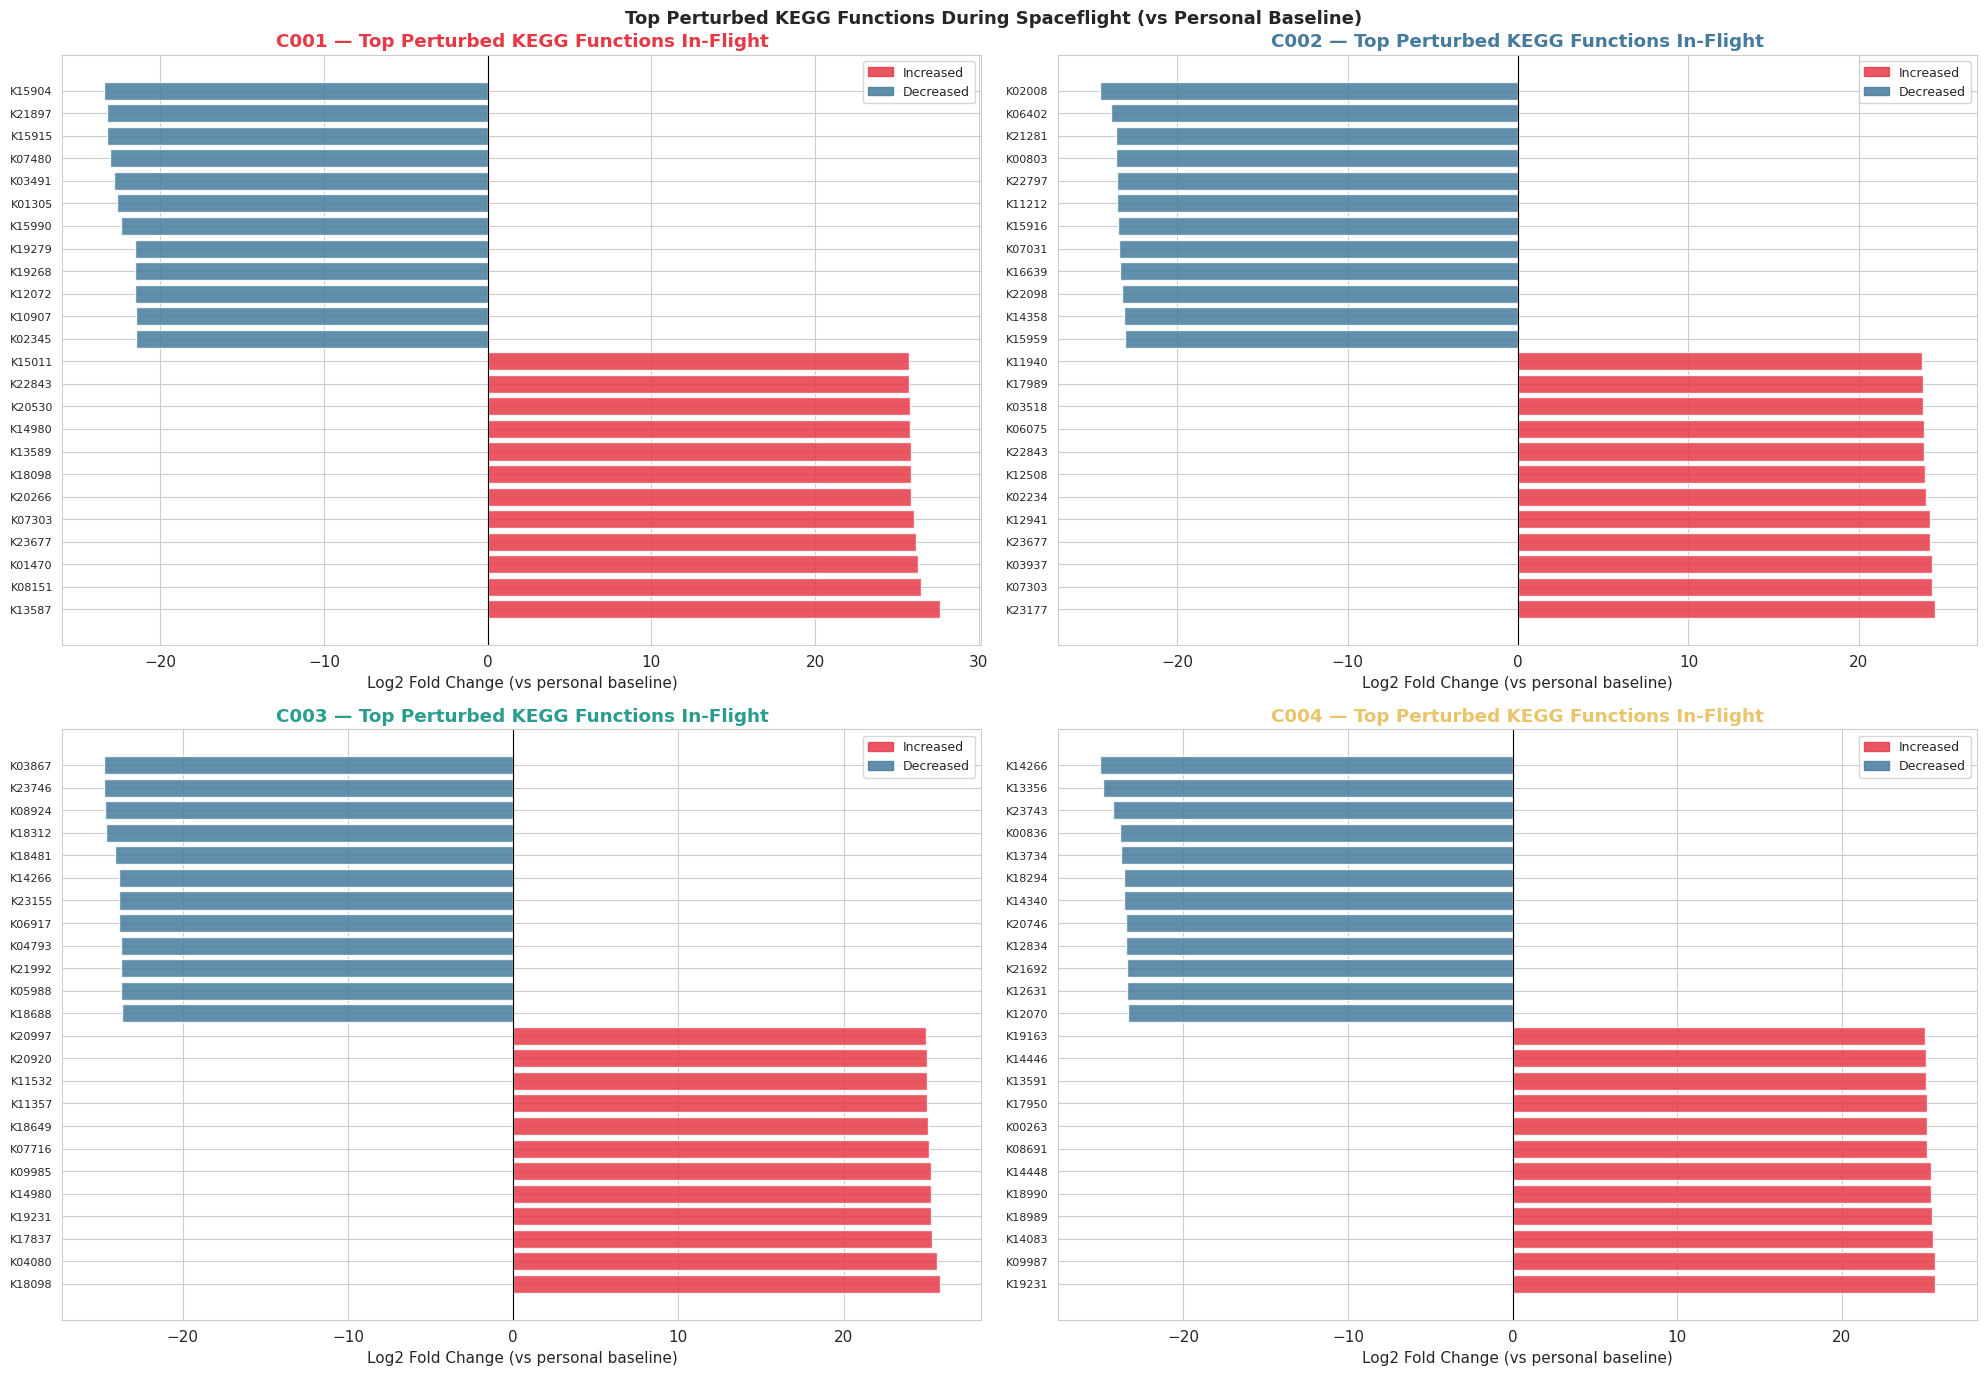

In [13]:
def top_perturbed_features(df, data_name, crew_id, timepoints=IN_FLIGHT, n=15):
    """
    Find features with greatest absolute log2 fold-change vs personal baseline
    during specified timepoints.
    """
    baseline = baselines[data_name][crew_id]
    # Average across in-flight timepoints and sites
    inflight_cols = get_crew_cols(df, crew_id, timepoints)
    if not inflight_cols:
        return pd.DataFrame()
    inflight_mean = df[inflight_cols].mean(axis=1)

    # Log2 fold change (add epsilon to avoid log(0))
    lfc = np.log2((inflight_mean + EPSILON) / (baseline + EPSILON))
    lfc = lfc[~lfc.isna() & ~np.isinf(lfc)]

    # Top N most perturbed (up or down)
    top_up   = lfc.nlargest(n)
    top_down = lfc.nsmallest(n)
    return pd.concat([top_up, top_down]).sort_values(ascending=False)

# Plot top perturbed KEGG functions for each crew member
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

for ax, crew in zip(axes, CREW_IDS):
    top = top_perturbed_features(kegg_numeric, 'kegg', crew, n=12)
    if top.empty:
        ax.set_title(f'{crew} — No data'); continue

    colors_bar = ['#E63946' if v > 0 else '#457B9D' for v in top.values]
    bars = ax.barh(range(len(top)), top.values, color=colors_bar, alpha=0.85)
    ax.set_yticks(range(len(top)))

    # Truncate long feature names
    labels = [str(idx)[:45] + '...' if len(str(idx)) > 45 else str(idx) for idx in top.index]
    ax.set_yticklabels(labels, fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Log2 Fold Change (vs personal baseline)')
    ax.set_title(f'{crew} — Top Perturbed KEGG Functions In-Flight',
                 fontweight='bold', color=COLORS[crew])

    up_patch   = mpatches.Patch(color='#E63946', alpha=0.85, label='Increased')
    down_patch = mpatches.Patch(color='#457B9D', alpha=0.85, label='Decreased')
    ax.legend(handles=[up_patch, down_patch], fontsize=9)

plt.suptitle('Top Perturbed KEGG Functions During Spaceflight (vs Personal Baseline)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('top_kegg_perturbations.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Composite Risk Score

Combine signals from all four data layers into a single **Composite Risk Score** per astronaut per timepoint. This integrates:
- KEGG functional disruption (weight: 0.25)
- Taxon abundance shift (weight: 0.25)
- Pathway activity disruption (weight: 0.30) ← slightly higher weight as most clinically interpretable
- Gene family disruption (weight: 0.20)

Scores are normalized 0–100 relative to the maximum observed across all crew and timepoints.

Composite Risk Scores (0–100 normalized):
      L-92  L-44  L-3   FD2    FD3   R+1  R+45  R+82
C001   0.0   0.0  0.0  25.5  100.0   5.8   6.8   3.9
C002   0.0   0.0  0.0  50.9   53.3  22.3  81.6  15.5
C003   0.0   0.0  0.0  15.3   33.3  11.4   6.3   6.8
C004   0.0   0.0  0.0   6.0   35.7   4.0   4.1   3.2


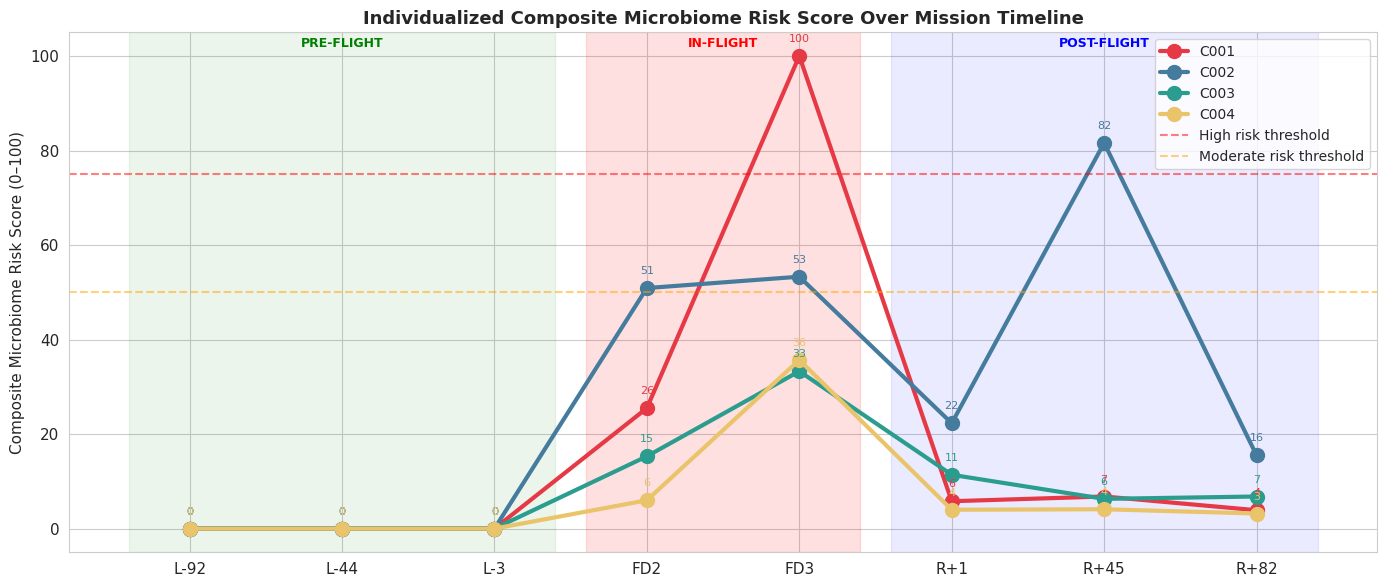

Figure saved: composite_risk_score.png


In [14]:
WEIGHTS = {'kegg': 0.25, 'tax': 0.25, 'pathway': 0.30, 'genefam': 0.20}

# Build composite score matrix: crew × timepoint
composite = pd.DataFrame(index=CREW_IDS, columns=TIMEPOINT_ORDER, dtype=float)

for crew in CREW_IDS:
    for tp in TIMEPOINT_ORDER:
        weighted_sum = 0
        total_weight = 0
        for dname, weight in WEIGHTS.items():
            dev_df = deviations[dname]
            if tp in dev_df.columns and not np.isnan(dev_df.loc[crew, tp]):
                weighted_sum += weight * dev_df.loc[crew, tp]
                total_weight += weight
        composite.loc[crew, tp] = weighted_sum / total_weight if total_weight > 0 else np.nan

composite = composite.astype(float)

# Normalize 0–100
max_val = composite.max().max()
composite_norm = (composite / max_val * 100).round(1)

print('Composite Risk Scores (0–100 normalized):')
print(composite_norm.to_string())

# ── Plot composite risk ──
fig, ax = plt.subplots(figsize=(14, 6))
available_tps = [tp for tp in TIMEPOINT_ORDER if not composite_norm[tp].isna().all()]

for crew in CREW_IDS:
    y = [composite_norm.loc[crew, tp] for tp in available_tps]
    ax.plot(range(len(available_tps)), y, marker='o', linewidth=3,
            color=COLORS[crew], label=crew, markersize=10)
    # Annotate each point
    for i, (tp, val) in enumerate(zip(available_tps, y)):
        if not np.isnan(val):
            ax.annotate(f'{val:.0f}', (i, val), textcoords='offset points',
                        xytext=(0, 10), ha='center', fontsize=8, color=COLORS[crew])

# Phase shading
tp_idx = {tp: i for i, tp in enumerate(available_tps)}
pre_r  = [tp_idx[t] for t in PRE_FLIGHT  if t in tp_idx]
in_r   = [tp_idx[t] for t in IN_FLIGHT   if t in tp_idx]
post_r = [tp_idx[t] for t in POST_FLIGHT if t in tp_idx]
if pre_r:  ax.axvspan(min(pre_r)-0.4,  max(pre_r)+0.4,  alpha=0.08, color='green')
if in_r:   ax.axvspan(min(in_r)-0.4,   max(in_r)+0.4,   alpha=0.12, color='red')
if post_r: ax.axvspan(min(post_r)-0.4, max(post_r)+0.4, alpha=0.08, color='blue')

# Risk zone lines
ax.axhline(75, color='red',    linestyle='--', alpha=0.5, linewidth=1.5, label='High risk threshold')
ax.axhline(50, color='orange', linestyle='--', alpha=0.5, linewidth=1.5, label='Moderate risk threshold')

ax.set_xticks(range(len(available_tps)))
ax.set_xticklabels(available_tps, fontsize=11)
ax.set_ylabel('Composite Microbiome Risk Score (0–100)', fontsize=11)
ax.set_title('Individualized Composite Microbiome Risk Score Over Mission Timeline',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')

# Phase labels
if pre_r:  ax.text(np.mean(pre_r),  ax.get_ylim()[1]*0.97, 'PRE-FLIGHT',  ha='center', color='green',  fontsize=9, fontweight='bold')
if in_r:   ax.text(np.mean(in_r),   ax.get_ylim()[1]*0.97, 'IN-FLIGHT',   ha='center', color='red',    fontsize=9, fontweight='bold')
if post_r: ax.text(np.mean(post_r), ax.get_ylim()[1]*0.97, 'POST-FLIGHT', ha='center', color='blue',   fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('composite_risk_score.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: composite_risk_score.png')

## 10. Per-Astronaut Risk Summary & Preparation Recommendations

Generate a plain-language risk summary and targeted recommendations for each crew member based on their individual data.

In [15]:
def generate_risk_summary(crew_id):
    """
    Generate a text risk summary and recommendations for one crew member.
    Based on their composite scores and recovery trajectory.
    """
    # Get composite scores
    row = composite_norm.loc[crew_id]
    available = row.dropna()

    # Peak disruption
    inflight_scores = {tp: row[tp] for tp in IN_FLIGHT if tp in row.index and not np.isnan(row[tp])}
    postflight_scores = {tp: row[tp] for tp in POST_FLIGHT if tp in row.index and not np.isnan(row[tp])}

    peak_inflight = max(inflight_scores.values()) if inflight_scores else np.nan
    latest_post   = list(postflight_scores.values())[-1] if postflight_scores else np.nan
    latest_post_tp = list(postflight_scores.keys())[-1] if postflight_scores else 'N/A'

    # Recovery delta
    recovery_delta = peak_inflight - latest_post if not np.isnan(peak_inflight) and not np.isnan(latest_post) else np.nan

    # Risk classification
    if np.isnan(peak_inflight):
        risk_level = 'UNKNOWN'
    elif peak_inflight >= 75:
        risk_level = '🔴 HIGH'
    elif peak_inflight >= 50:
        risk_level = '🟡 MODERATE'
    else:
        risk_level = '🟢 LOW'

    if np.isnan(latest_post):
        recovery_status = 'UNKNOWN'
    elif latest_post < 25:
        recovery_status = '✅ GOOD — near personal baseline'
    elif latest_post < 50:
        recovery_status = '⚠️  PARTIAL — still elevated'
    else:
        recovery_status = '🚨 POOR — significantly above baseline'

    # Per-data-type peaks
    data_peaks = {}
    for dname, df in data_pairs:
        dev_df = deviations[dname]
        in_scores = [dev_df.loc[crew_id, tp] for tp in IN_FLIGHT
                     if tp in dev_df.columns and not np.isnan(dev_df.loc[crew_id, tp])]
        data_peaks[dname] = max(in_scores) if in_scores else np.nan

    worst_layer = max(data_peaks, key=lambda k: data_peaks[k] if not np.isnan(data_peaks[k]) else -1)

    print(f"""
{'='*60}
ASTRONAUT {crew_id} — INDIVIDUALIZED RISK PROFILE
{'='*60}

FLIGHT DISRUPTION RISK:     {risk_level}
Peak composite score:       {peak_inflight:.1f}/100

RECOVERY STATUS (@{latest_post_tp}): {recovery_status}
Recovery score:             {latest_post:.1f}/100
Recovery delta:             {recovery_delta:.1f} points

DATA LAYER BREAKDOWN (peak in-flight %):
  KEGG Functions:   {data_peaks.get('kegg', np.nan):.1f}%
  Taxon Abundance:  {data_peaks.get('tax', np.nan):.1f}%
  Pathway Activity: {data_peaks.get('pathway', np.nan):.1f}%
  Gene Families:    {data_peaks.get('genefam', np.nan):.1f}%
  Most disrupted layer: {worst_layer.upper()}

PREPARATION RECOMMENDATIONS FOR FUTURE MISSIONS:
""")

    recs = []
    if data_peaks.get('tax', 0) > 50:
        recs.append('  • Pre-flight probiotic/microbiome stabilization protocol'
                    ' (taxon abundance highly disrupted)')
    if data_peaks.get('pathway', 0) > 50:
        recs.append('  • Targeted nutritional supplementation to support disrupted'
                    ' metabolic pathways pre- and in-flight')
    if data_peaks.get('kegg', 0) > 50:
        recs.append('  • Monitor immune-modulating microbial functions;'
                    ' consider prophylactic immune support')
    if data_peaks.get('genefam', 0) > 50:
        recs.append('  • Gene-level monitoring flagged — consider targeted'
                    ' antibiotic resistance gene screening pre-flight')
    if not np.isnan(latest_post) and latest_post > 40:
        recs.append(f'  • Extended post-flight recovery protocol needed'
                    f' (score still {latest_post:.0f}/100 at {latest_post_tp})')
    if not recs:
        recs.append('  • Microbiome appeared stable — maintain current baseline '
                    'health protocols')
    recs.append('  • Collect L-92 and L-44 baseline samples for future missions'
                ' to improve personal baseline quality')
    recs.append('  • Continue R+82 monitoring; consider extended to R+180'
                ' to confirm full microbiome recovery')

    for r in recs:
        print(r)

# Run for all crew members
for crew in CREW_IDS:
    generate_risk_summary(crew)


ASTRONAUT C001 — INDIVIDUALIZED RISK PROFILE

FLIGHT DISRUPTION RISK:     🔴 HIGH
Peak composite score:       100.0/100

RECOVERY STATUS (@R+82): ✅ GOOD — near personal baseline
Recovery score:             3.9/100
Recovery delta:             96.1 points

DATA LAYER BREAKDOWN (peak in-flight %):
  KEGG Functions:   171027843.5%
  Taxon Abundance:  77527543.3%
  Pathway Activity: 8691543.5%
  Gene Families:    5061747.4%
  Most disrupted layer: KEGG

PREPARATION RECOMMENDATIONS FOR FUTURE MISSIONS:

  • Pre-flight probiotic/microbiome stabilization protocol (taxon abundance highly disrupted)
  • Targeted nutritional supplementation to support disrupted metabolic pathways pre- and in-flight
  • Monitor immune-modulating microbial functions; consider prophylactic immune support
  • Gene-level monitoring flagged — consider targeted antibiotic resistance gene screening pre-flight
  • Collect L-92 and L-44 baseline samples for future missions to improve personal baseline quality
  • Continue 

## 11. Cross-Crew Comparison — Who Was Most Resilient?

Compare resilience across crew members to identify individual risk factors that could inform crew selection and preparation for future missions.

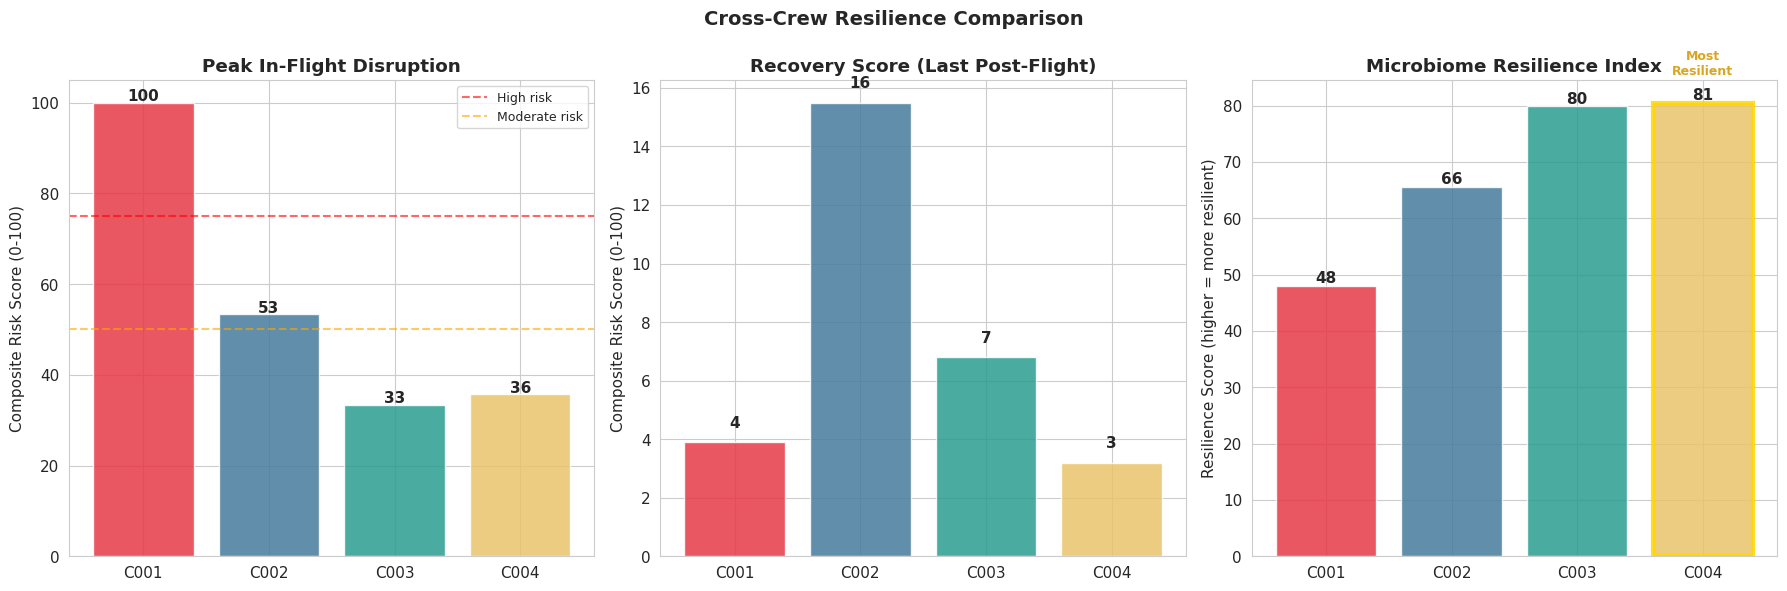

Figure saved: resilience_comparison.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Peak disruption comparison
ax = axes[0]
peaks = []
for crew in CREW_IDS:
    inflight = [composite_norm.loc[crew, tp] for tp in IN_FLIGHT
                if tp in composite_norm.columns and not np.isnan(composite_norm.loc[crew, tp])]
    peaks.append(max(inflight) if inflight else np.nan)
bars = ax.bar(CREW_IDS, peaks, color=[COLORS[c] for c in CREW_IDS], alpha=0.85, edgecolor='white')
for bar, val in zip(bars, peaks):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.0f}',
                ha='center', fontsize=11, fontweight='bold')
ax.axhline(75, color='red',    linestyle='--', alpha=0.6, label='High risk')
ax.axhline(50, color='orange', linestyle='--', alpha=0.6, label='Moderate risk')
ax.set_title('Peak In-Flight Disruption', fontweight='bold')
ax.set_ylabel('Composite Risk Score (0-100)')
ax.legend(fontsize=9)

# 2. Recovery score at last timepoint
ax = axes[1]
recs = []
for crew in CREW_IDS:
    post = {tp: composite_norm.loc[crew, tp] for tp in POST_FLIGHT
            if tp in composite_norm.columns and not np.isnan(composite_norm.loc[crew, tp])}
    recs.append(list(post.values())[-1] if post else np.nan)
bars = ax.bar(CREW_IDS, recs, color=[COLORS[c] for c in CREW_IDS], alpha=0.85, edgecolor='white')
for bar, val in zip(bars, recs):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.0f}',
                ha='center', fontsize=11, fontweight='bold')
ax.set_title('Recovery Score (Last Post-Flight)', fontweight='bold')
ax.set_ylabel('Composite Risk Score (0-100)')

# 3. Resilience index: lower peak + faster recovery = more resilient
ax = axes[2]
resilience = []
for p, r in zip(peaks, recs):
    if not np.isnan(p) and not np.isnan(r):
        # Resilience = inverse of combined peak and residual
        res = 100 - (0.5 * p + 0.5 * r)
    else:
        res = np.nan
    resilience.append(res)
bars = ax.bar(CREW_IDS, resilience, color=[COLORS[c] for c in CREW_IDS], alpha=0.85, edgecolor='white')
for bar, val in zip(bars, resilience):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.0f}',
                ha='center', fontsize=11, fontweight='bold')
ax.set_title('Microbiome Resilience Index', fontweight='bold')
ax.set_ylabel('Resilience Score (higher = more resilient)')

most_resilient = CREW_IDS[np.nanargmax(resilience)]
ax.get_children()[CREW_IDS.index(most_resilient)].set_edgecolor('gold')
ax.get_children()[CREW_IDS.index(most_resilient)].set_linewidth(3)
ax.annotate('Most\nResilient', xy=(CREW_IDS.index(most_resilient), resilience[CREW_IDS.index(most_resilient)]),
            xytext=(CREW_IDS.index(most_resilient), resilience[CREW_IDS.index(most_resilient)] + 5),
            ha='center', fontsize=9, color='goldenrod', fontweight='bold')

plt.suptitle('Cross-Crew Resilience Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('resilience_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: resilience_comparison.png')

## 12. Export Results for GitHub Repository

Save all key outputs as files ready to commit to the repository.

In [17]:
import os
os.makedirs('outputs', exist_ok=True)

# Save deviation tables
for dname in ['kegg', 'tax', 'pathway', 'genefam']:
    deviations[dname].to_csv(f'outputs/deviation_{dname}.csv')
    print(f'Saved: outputs/deviation_{dname}.csv')

# Save composite risk
composite_norm.to_csv('outputs/composite_risk_scores.csv')
print('Saved: outputs/composite_risk_scores.csv')

# Save recovery summary
recovery_df.to_csv('outputs/recovery_summary.csv')
print('Saved: outputs/recovery_summary.csv')

print('\n✅ All outputs saved to outputs/ folder')
print('Ready to commit to GitHub repository!')

Saved: outputs/deviation_kegg.csv
Saved: outputs/deviation_tax.csv
Saved: outputs/deviation_pathway.csv
Saved: outputs/deviation_genefam.csv
Saved: outputs/composite_risk_scores.csv
Saved: outputs/recovery_summary.csv

✅ All outputs saved to outputs/ folder
Ready to commit to GitHub repository!


## 13. GitHub Repository Setup

Run this cell to push everything to your GitHub repository directly from Colab.

**First time setup:** Go to `File → Save a copy in GitHub` to link this notebook.

Then use the cell below to push output files.

In [18]:
# ── GitHub push (run after linking repo via File → Save a copy in GitHub) ──
#
# Replace with your actual repo details:
# GITHUB_REPO = 'https://github.com/SamM-UATX/TorchlightSummitAnalysis.git'
# GITHUB_TOKEN = 'your_personal_access_token'  # store as Colab secret!
#
# from google.colab import userdata
# token = userdata.get('GITHUB_TOKEN')
#
# !git config --global user.email 'you@example.com'
# !git config --global user.name 'Your Name'
# !git clone https://{token}@github.com/{GITHUB_REPO}.git repo
# !cp -r outputs/ repo/outputs/
# !cp *.png repo/visualizations/
# !cd repo && git add . && git commit -m 'Add risk analysis outputs' && git push

print('📋 GitHub push template ready — fill in your repo details above, then uncomment.')
print('💡 Tip: Store your GitHub token as a Colab Secret (🔑 icon in left sidebar)')

📋 GitHub push template ready — fill in your repo details above, then uncomment.
💡 Tip: Store your GitHub token as a Colab Secret (🔑 icon in left sidebar)
